In [1]:
# Pipeline Configuration
RUN_MODE = "test"
TEST_SAMPLE_SIZE = 10
MAX_WORKERS = 4
CHUNK_SIZE = 500
MAX_RETRIES = 5
TIMEOUT = 30
ENABLE_CACHE = True
ENABLE_CHECKPOINT = True
SAVE_PREVIEW_IMAGES = True
PIPELINE_VERSION = "1.0.0"


# Feature Statistics Report\nCalculate summary statistics and draw histograms/correlation matrices.

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

df_path = "../../data/processed/merged_features.csv"
if not os.path.exists(df_path):
    print("No merged_features.csv found.")
else:
    df = pd.read_csv(df_path)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [c for c in numeric_cols if c not in ["POINT_ID", "Latitude", "Longitude"]]
    # Summary statistics
    stats = df[numeric_cols].describe().T
    stats["median"] = df[numeric_cols].median()
    stats["missing_count"] = df[numeric_cols].isna().sum()
    os.makedirs("../../outputs/reports", exist_ok=True)
    stats.to_csv("../../outputs/reports/feature_statistics.csv")
    print("Summary statistics calculated and saved to outputs/reports/feature_statistics.csv")
    print(stats[["mean", "std", "min", "median", "max", "missing_count"]])



Summary statistics calculated and saved to outputs/reports/feature_statistics.csv
                             mean        std          min      median  \
pH_H2O                   6.259460   1.319465     3.340000    6.290000   
pH_CaCl2                 5.706427   1.398586     2.600000    5.800000   
EC                      18.389964  25.560630     0.240000   13.950000   
sentinel_ok              1.000000   0.000000     1.000000    1.000000   
NDVI                     0.591774   0.194314     0.280460    0.594878   
EVI                      0.326161   0.094438     0.173469    0.345573   
SAVI                     0.311540   0.088131     0.172111    0.321315   
MSAVI                    0.284692   0.090684     0.153363    0.290911   
GNDVI                    0.553873   0.125015     0.379334    0.543223   
NDMI                    -0.096840   0.028410    -0.129880   -0.103188   
NDWI                    -0.553873   0.125015    -0.761242   -0.543223   
BSI                      0.109884   0.0147

C:\Users\Moaaz\AppData\Local\Temp\ipykernel_31784\336867722.py:11: DtypeWarning: Columns (8,10,12,13,14,15,17,18,31,33,34,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df_path)


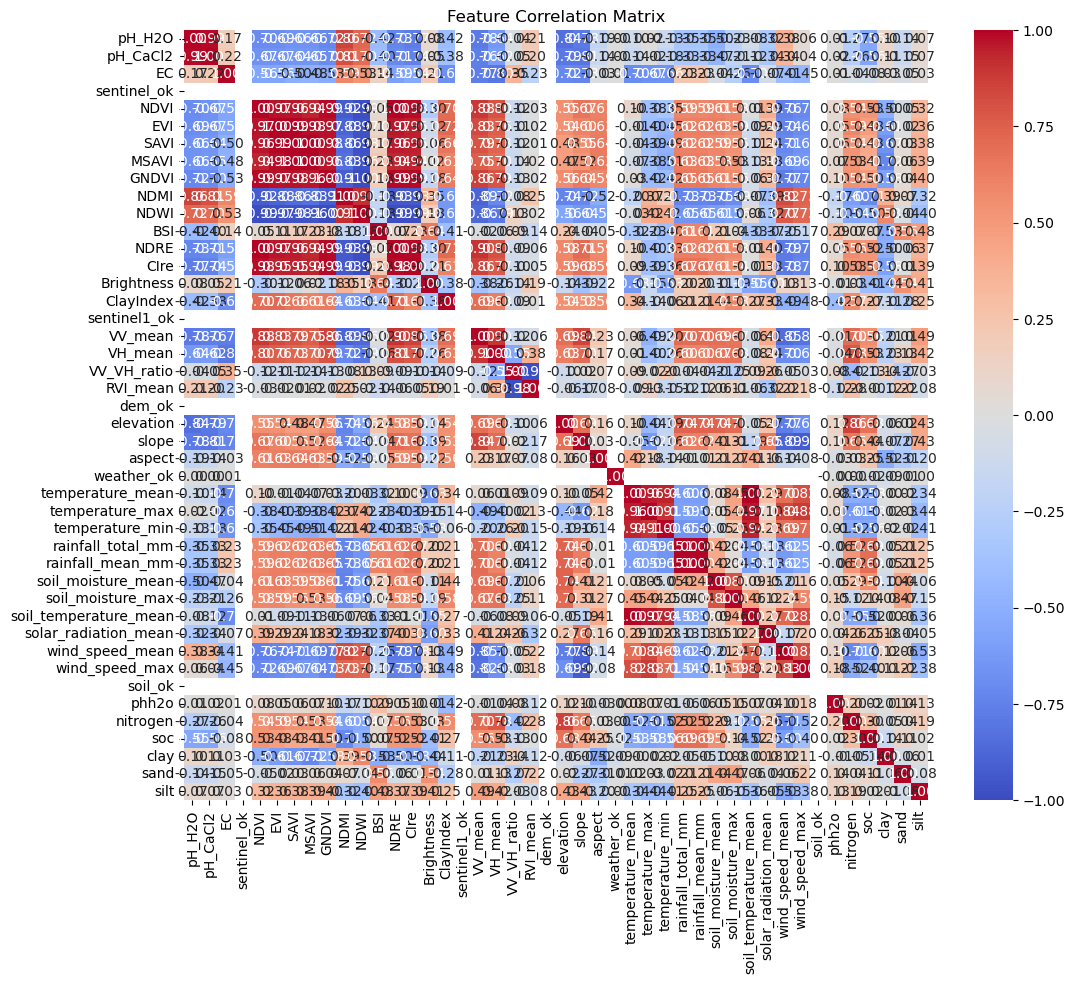

In [3]:
if 'df' in locals() and len(numeric_cols) > 0:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
    plt.title("Feature Correlation Matrix")
    os.makedirs("../../outputs/figures", exist_ok=True)
    plt.savefig("../../outputs/figures/correlation_matrix.png", bbox_inches="tight")
    plt.show()



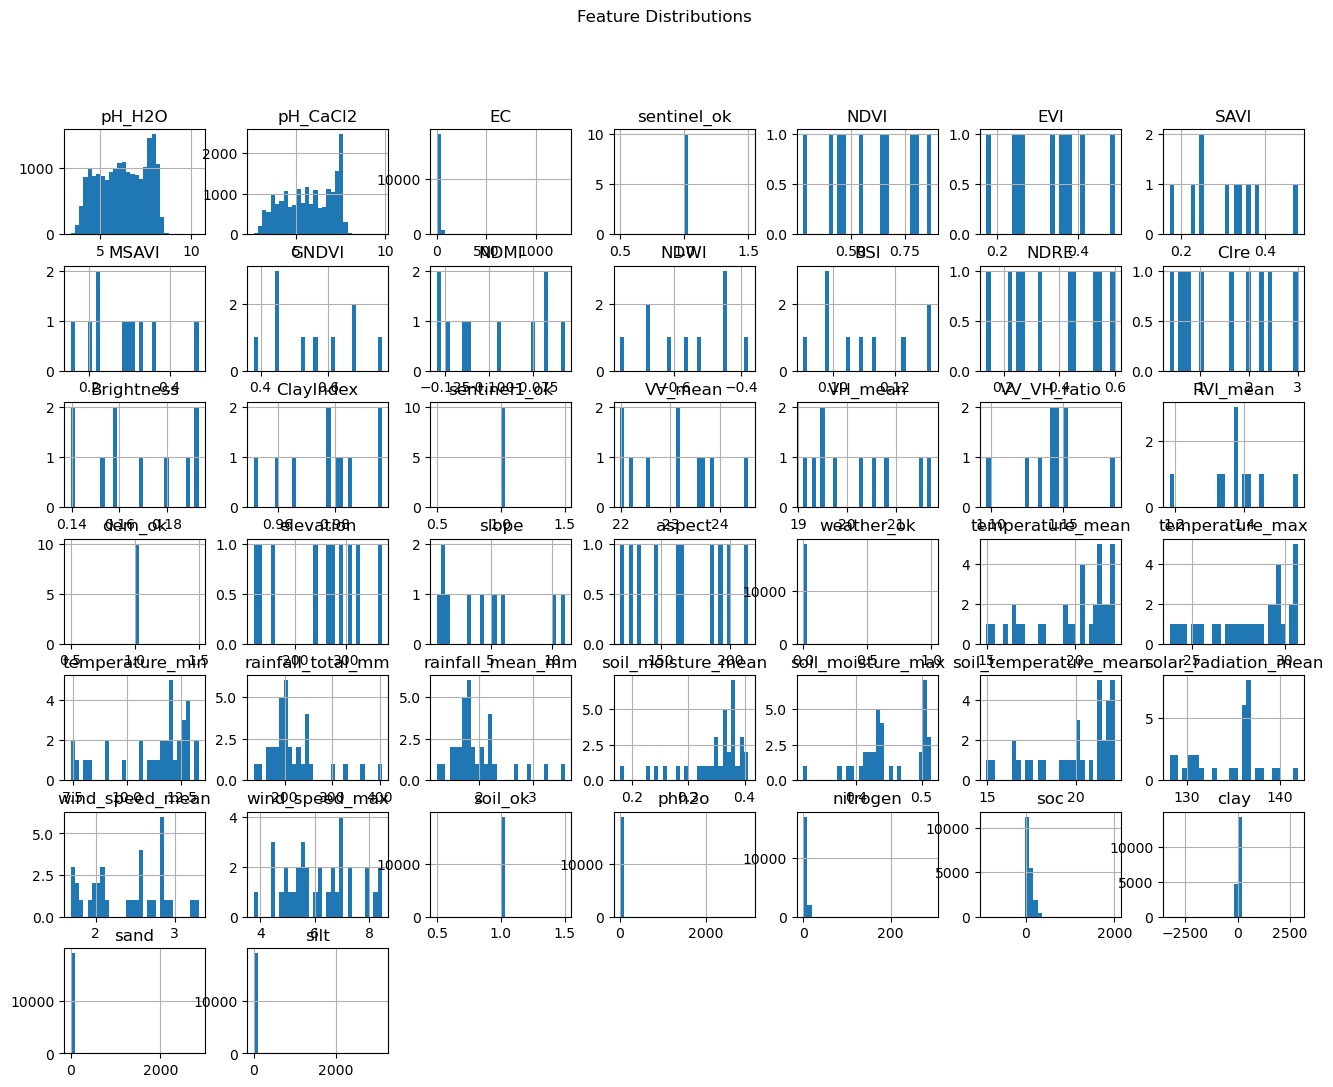

In [4]:
if 'df' in locals() and len(numeric_cols) > 0:
    df[numeric_cols].hist(figsize=(16, 12), bins=30)
    plt.suptitle("Feature Distributions")
    plt.savefig("../../outputs/figures/feature_histograms.png", bbox_inches="tight")
    plt.show()

